Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None

Missing values handled. Remaining NaNs in 'area': 0
Outliers handled. Original rows: 545, Cleaned rows: 530

PCA Explained Variance Ra

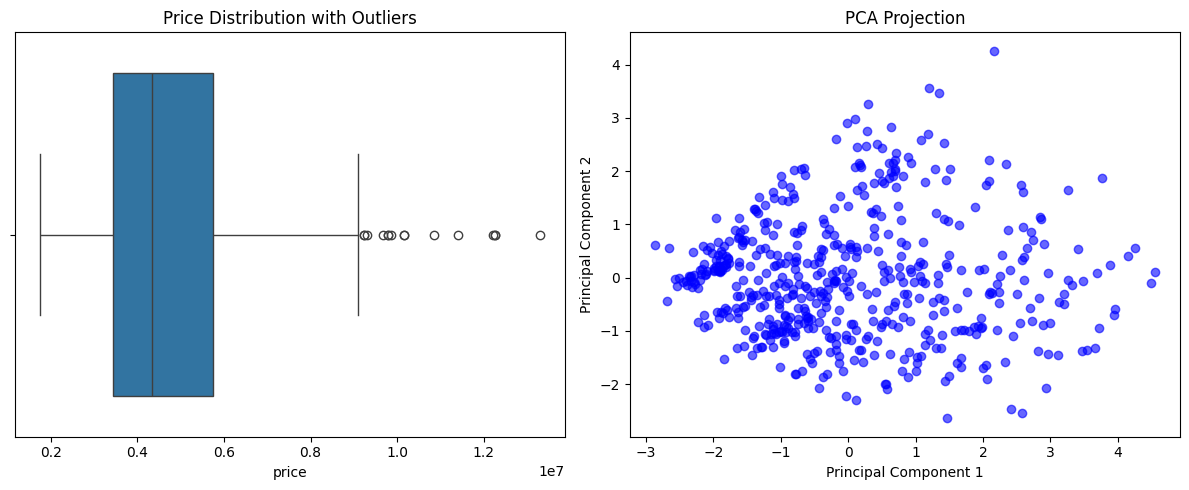

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

# 1. Load Dataset
# In Colab, you can upload the file using the folder icon on the left
# or use: from google.colab import files; files.upload()
df = pd.read_csv('Housing.csv')

# --- Task 1: Identify Data Quality Issues ---
# Issues: Scale inconsistency between price/area, presence of outliers,
# and categorical text data (yes/no) that needs encoding for ML.
print("Dataset Info:")
print(df.info())

# --- Task 2: Missing Value Strategy ---
# Introducing artificial missing values for demonstration as per Lab 4
df_missing = df.copy()
df_missing.loc[10:20, 'area'] = np.nan

# Strategy: Median Imputation (Robust to outliers in house area)
area_median = df_missing['area'].median()
df_missing['area'] = df_missing['area'].fillna(area_median)
print(f"\nMissing values handled. Remaining NaNs in 'area': {df_missing['area'].isna().sum()}")

# --- Task 3: Handle Outliers using IQR ---
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtering outliers
df_cleaned = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)].copy()
print(f"Outliers handled. Original rows: {len(df)}, Cleaned rows: {len(df_cleaned)}")

# --- Task 4: Normalize Numerical Features ---
cols_to_scale = ['price', 'area']

# Min-Max Scaling (Scales to 0-1 range)
mm_scaler = MinMaxScaler()
df_minmax = df_cleaned.copy()
df_minmax[cols_to_scale] = mm_scaler.fit_transform(df_cleaned[cols_to_scale])

# Z-Score Normalization (Standardization: Mean=0, Std=1)
std_scaler = StandardScaler()
df_zscore = df_cleaned.copy()
df_zscore[cols_to_scale] = std_scaler.fit_transform(df_cleaned[cols_to_scale])

# --- Task 5: PCA and Explained Variance ---
# Use numerical columns for PCA
num_cols = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']
X = df_cleaned[num_cols]

# PCA requires standardized data
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
pc_data = pca.fit_transform(X_scaled)

print(f"\nPCA Explained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Total variance captured by 2 components: {np.sum(pca.explained_variance_ratio_):.2%}")

# --- Visualizing Results ---
plt.figure(figsize=(12, 5))

# Boxplot for Outliers
plt.subplot(1, 2, 1)
sns.boxplot(x=df['price'])
plt.title('Price Distribution with Outliers')

# PCA Scatter Plot
plt.subplot(1, 2, 2)
plt.scatter(pc_data[:, 0], pc_data[:, 1], alpha=0.6, c='blue')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection')

plt.tight_layout()
plt.show()